# Breast Cancer Prediction Project

Welcome to the Breast Cancer Prediction project! 🎯

In this beginner-friendly notebook, we'll walk through a step-by-step machine learning pipeline to predict whether a tumor is malignant or benign based on various features.

## 🔍 Objective

Our goal is to build a machine learning model that can accurately predict whether a tumor is **malignant (M)** or **benign (B)** based on a set of measurements.

We'll use the dataset `Cancer_Data.csv` for this purpose.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score)

## 📥 Step 1: Load the Dataset

In [32]:
# Load the dataset
data = pd.read_csv("Cancer_Data.csv")

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 🔍 Step 2: Explore the Dataset

In [33]:
data.info()

print("Diagnosis value counts:")
print(data["diagnosis"].value_counts())

print("\nMissing values:")
print(data.isnull().sum()[data.isnull().sum() > 0])

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

## 🧹 Step 3: Clean the Data

We'll remove any unnecessary columns and handle missing values.

In [34]:
# Drop unnecessary columns
data = data.drop(["id"], axis=1)

if "Unnamed: 32" in data.columns:
    data = data.drop(["Unnamed: 32"], axis=1)

print("Remaining columns:", data.shape[1])
data.head()

Remaining columns: 31


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 📊 Step 4: Visualize the Data

C:\Users\asus\AppData\Local\Temp\ipykernel_1980\3537232393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=data, palette="Set2")


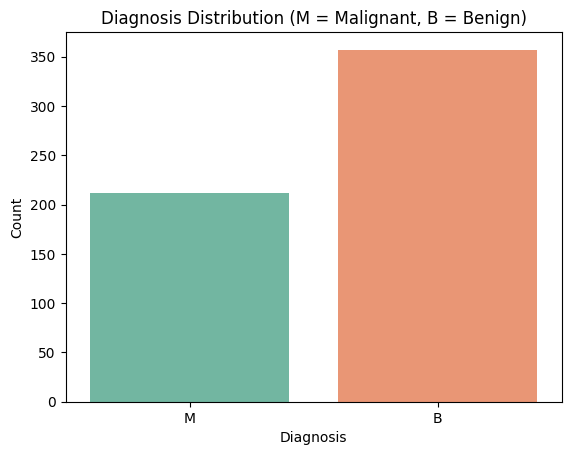

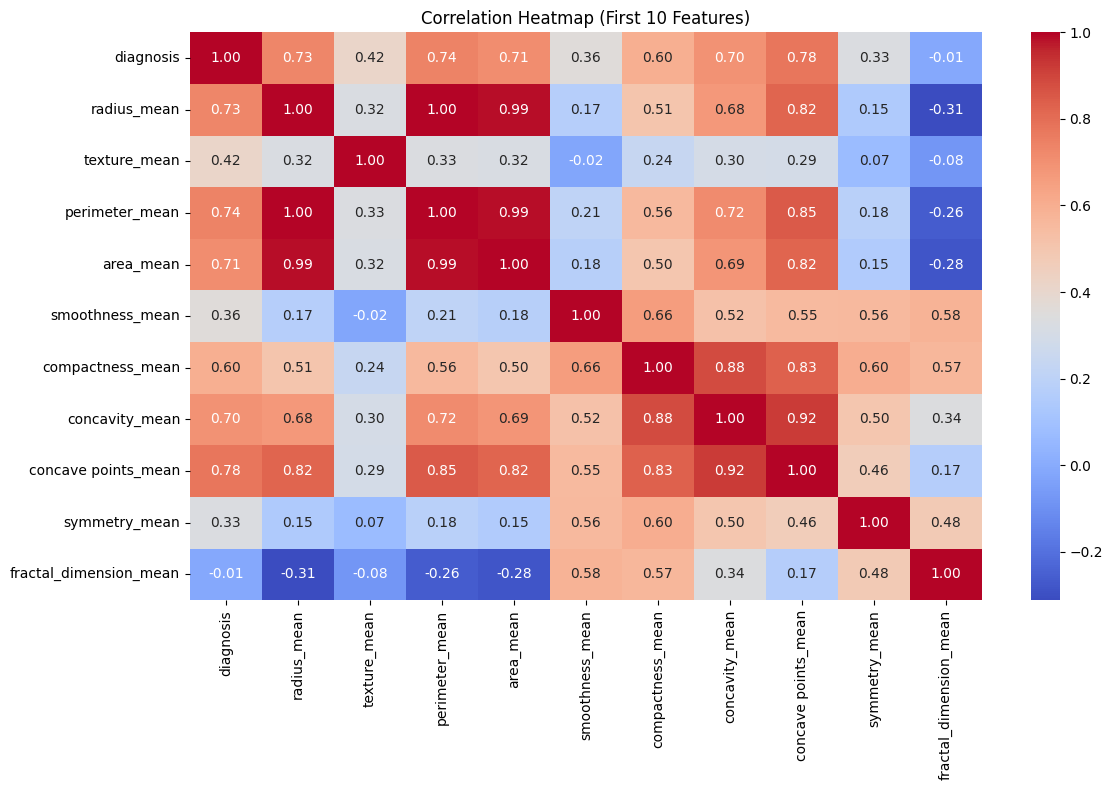

In [35]:
# Class distribution
sns.countplot(x="diagnosis", data=data, palette="Set2")
plt.title("Diagnosis Distribution (M = Malignant, B = Benign)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# Correlation heatmap (first 10 features)
temp = data.copy()
temp["diagnosis"] = temp["diagnosis"].map({"B": 0, "M": 1})

plt.figure(figsize=(12, 8))
sns.heatmap(temp.iloc[:, :11].corr(), annot=True,
            fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (First 10 Features)")
plt.tight_layout()
plt.show()

## ⚙️ Step 5: Preprocess the Data

In [36]:
# Convert diagnosis column to 0 (benign) and 1 (malignant)

# Split features and labels

# Split into training and testing sets

# Scale the features

# Convert diagnosis column into numbers
# Convert diagnosis column
# Convert diagnosis column
# Convert diagnosis column
# Convert diagnosis values
# Convert diagnosis values
# Encode target: Benign = 0, Malignant = 1
# Convert diagnosis column
# Convert diagnosis values
# Convert diagnosis values
# Encode target: Benign = 0, Malignant = 1
data["diagnosis"] = data["diagnosis"].map({"B": 0, "M": 1})

# Features and target
X = data.drop("diagnosis", axis=1)
y = data["diagnosis"]

# Train / test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print("Preprocessing Done!")

Training set size: (455, 30)
Test set size:     (114, 30)
Preprocessing Done!


## 🤖 Step 6: Train a Machine Learning Model

Model training complete!
Accuracy: 0.9736842105263158

Classification Report:

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        71
   Malignant       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



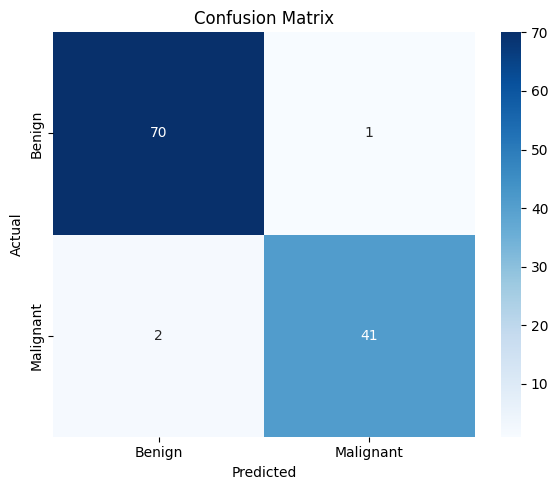

In [37]:
# Use Logistic Regression
# Convert diagnosis column
data['diagnosis'] = data['diagnosis'].map({'B': 0, 'M': 1})
# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("Model training complete!")

# Predict
y_pred = model.predict(X_test)

# Accuracy & classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred,
      target_names=["Benign", "Malignant"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 🧪 Step 7: Evaluate the Model

In [40]:
# Step 7: Evaluate the Model

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.9736842105263158

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## ✅ Conclusion

Awesome work! 🎉

You've successfully built a breast cancer prediction model using Logistic Regression. You explored the data, cleaned it, visualized it, trained a model, and evaluated its performance.

### 🚀 Next Steps
- Try different models like RandomForest or SVM
- Perform feature selection
- Tune hyperparameters for better accuracy